# Flowshop Example (Cyclic Workshop)

This notebook presents the application of (max,+) algebra to cyclic flowshop workshops, following the ScicosLab toolbox example.

This demo comes from J.-P. Quadrat's notes *Maxplus Algebra in Scilab and Applications* ([chine.pdf](https://jpquadrat.github.io/chine.pdf) and [boutheon.pdf](https://jpquadrat.github.io/boutheon.pdf)).

## Flowshop Model

- **Parts** are carried on **pallets**. When tasks on a part are finished, the pallet starts another cycle with another part of the same class.
- Each part visits machines in sequence, never coming back to the same machine.
- For a given task, we can have several machines (a "class"). Machines visit parts in sequence.
- The flowshop is defined by a matrix describing resources and processing times.
- Each **row** corresponds to a machine class.
- Each **column** corresponds to a part class.
- Entries are **processing times**.
- If a part class doesn't need a machine class, the entry is $-\infty$ (`mp0` or `ε`).

### Graphical example

![Flowshop: timed event graph with the critical cycle highlighted in red](flowshop.png)

*Figure — A small flowshop (2 machine classes `M1`, `M2` × 3 part classes `P1`, `P2`, `P3`) drawn with [TimedPetriNetEditor](https://github.com/Lecrapouille/TimedPetriNetEditor). It is a **timed event graph** (a subclass of timed Petri nets): for clarity the places are not drawn explicitly — only their **tokens** (the dot followed by a count, e.g. `•1`) and the **task durations** (the number on each arc, in time units) are shown. Transitions `M1_P1`, `M2_P2`, … are the events "start the task for part class j on machine class i".*

**Purpose of the model.** From this graph we compute the **asymptotic cycle time** $\lambda$ of the workshop — the average time between two successive completions of each part. That $\lambda$ is the (max,+) eigenvalue of the graph and coincides with the **critical circuit**: the cycle of the graph whose ratio (sum of durations) / (sum of tokens) is maximal. It sets the pace; any optimisation has to identify and relax this circuit. **On the figure, the critical circuit is drawn in red** (its arcs and transitions).

The rest of this notebook walks through the `MaxPlus.jl` toolbox on a **larger flowshop** (8 machine classes × 6 part classes) taken from J.-P. Quadrat's notes.

In [1]:
push!(LOAD_PATH, pwd())
using MaxPlus, SparseArrays

## Data: Processing Times `PT`

The flowshop studied here has **8 machine classes** (rows) and **6 part classes** (columns). The matrix `PT` (*Processing Times*) describes the workshop **schedule**:

- `PT[i, j]` = duration (in time units, e.g. minutes or hours — (max,+) algebra does not fix the unit) of the task that machine class `i` performs on part class `j`;
- an empty entry `.` corresponds to `mp0 = ε = -∞` and means *"this part class does not visit this machine class"* (no task, hence no duration constraint);
- a numeric entry encodes both the **resource used** (machine class `i`) **and** the **processing time**.

In the example below, `PT[1, 2] = 3.9` means: *a part of class `2` keeps a machine of class `1` busy for `3.9` time units*. The last row (`1.5, 1.5, …`) and the one above (`1, 1, …`) typically model shared steps (handling, inspection, …) that every part has to traverse.

In [2]:
PT = MP.([
    2    3.9  0.95 1.1  0.7  1.4
    mp0  mp0  2    1.2  mp0  1.7
    3.7  mp0  2.2  mp0  6.4  mp0
    mp0  mp0  2    mp0  1    1
    1.7  3.1  3    mp0  1.3  mp0
    0.5  3.2  4.3  1.9  1.6  0.4
    1    1    1    1    1    1
    1.5  1.5  1.5  1.2  1.2  1.2
])

8×6 (max,+) dense matrix:
    2   3.9   0.95   1.1   0.7   1.4
    .     .      2   1.2     .   1.7
  3.7     .    2.2     .   6.4     .
    .     .      2     .     1     1
  1.7   3.1      3     .   1.3     .
  0.5   3.2    4.3   1.9   1.6   0.4
    1     1      1     1     1     1
  1.5   1.5    1.5   1.2   1.2   1.2


### Number of Pallets/Machines per Class

The matrix `PT` does not say **how many copies** exist for each class; this is described separately by two vectors `nm` and `np`:

- `nm[i]` = number of **machines** available in class `i`. This is the buffer size in front of the resource: a machine processes one part at a time, so `nm[i]` tokens let `nm[i]` parts be served in parallel by that class.
- `np[j]` = number of **pallets** circulating for part class `j`. A pallet is released at the end of its part's cycle and immediately picks up a new part of the same class; `np[j]` therefore bounds the maximum number of parts of class `j` simultaneously in process.

These two vectors are **the optimisation knobs** of the flowshop: raising `nm[i]` or `np[j]` may lower the cycle time $\lambda$ until some other circuit becomes critical.

We first read the dimensions of `PT` and pick the **simplest periodic case** with a single machine and a single pallet per class:

In [3]:
nmach, npiece = size(PT)
println("Number of machine classes: $nmach, Number of part classes: $npiece")

nm = ones(Int, nmach)  # 1 machine per class
np = ones(Int, npiece) # 1 pallet per class

Number of machine classes: 8, Number of part classes: 6


6-element Vector{Int64}:
 1
 1
 1
 1
 1
 1

## Graph (T, N) and Spectral Analysis

The flowshop has a natural **timed event graph** representation (see the figure at the top of this notebook): each transition is an event of the workshop ("start the task for part `j` on machine `i`"), each arc carries both a **duration** (processing time) and a **token count** (initial resources: available machines, ready pallets). The function `flowshop_graph` extracts from `PT`, `nm`, `np` two sparse matrices that describe exactly this graph:

- `T[k, ℓ]` = duration carried by the arc from transition `ℓ` to transition `k` (`-∞` if no arc);
- `N[k, ℓ]` = number of tokens carried by that same arc.

`T` and `N` share the same sparsity pattern (same non-zero positions) — one gives the *time* weight, the other the *token* weight of each arc.

In [4]:
T, N = flowshop_graph(PT, Float64.(nm), Float64.(np))
println("T: ", size(T), " non-zeros: ", nnz(T))
println("N: ", size(N), " non-zeros: ", nnz(N))

T: (

65, 65) non-zeros: 102
N: (65, 65) non-zeros: 102


### Throughput Computation (Semi-Howard)

**Spectral analysis in (max,+).** Just as in classical algebra the asymptotic behaviour of a matrix $A$ is captured by its eigenvalues ($Ax = \lambda x$), we look in (max,+) for a scalar $\lambda$ and a vector $v$ such that

$$A \otimes v = \lambda \otimes v
\quad\text{(in classical notation: } \max_j \bigl(A_{ij} + v_j\bigr) = \lambda + v_i \text{ for every } i\text{)}.$$

Such a $\lambda$ is a **(max,+) eigenvalue** and $v$ an **eigenvector**. For a strongly connected timed event graph the eigenvalue is **unique** and equals the **asymptotic cycle time** $\lambda$ of the system: after a transient phase, every transition fires every $\lambda$ time units. The workshop throughput is then $1 / \lambda$ parts per unit time.

**Howard / Semi-Howard algorithm.** Howard (1960) computes this eigenvalue by *policy iteration*: at each step it picks for every transition the incoming arc that maximises a certain ratio, and computes the eigenvalue of the sub-graph induced by those choices. Convergence is quadratic in practice. The **Semi-Howard** variant (Cochet-Terrasson, Cohen, Gaubert, McGettrick, Quadrat) operates directly on the `(T, N)` pair of a timed event graph, without forming the associated matrix.

**Returned policy.** Besides the eigenvalue, the algorithm returns a *policy vector* (`r.policy`): for every transition `k` it records the **optimal predecessor** chosen at convergence. The arcs $(\text{policy}[k] \to k)$ form the **policy graph**, whose circuits are exactly the **critical circuits** — the cycles achieving the maximum (sum of durations) / (sum of tokens) = $\lambda$. This subgraph (drawn in red on the introductory figure) is what sets the pace: to reduce $\lambda$ one has to act on an arc of the critical circuit (add a machine, a pallet, or shorten a task).

In [5]:
r = semihoward(T, N)
λ = plustimes(r.eigenvalues[1])
println("Eigenvalue (cycle time): λ = $λ")

Eigenvalue (cycle time): λ = 16.95


### Visualising the policy with `TimedPetriNetEditor`

`MaxPlus.jl` computes the eigenvalue and the policy, but it does not draw the graph. To **visualise** the network and **highlight** the critical circuit (the policy returned by Semi-Howard, in red as on the introductory figure), use the companion editor [TimedPetriNetEditor](https://github.com/Lecrapouille/TimedPetriNetEditor) — a timed Petri net editor written in **C++** — and its **(work-in-progress) Julia port** [TimedPetriNetEditor.jl](https://github.com/Lecrapouille/TimedPetriNetEditor.jl).

The pipeline is straightforward:

1. `MaxPlus.save_flowshop(PT, nm, np, "demo.flowshop")` writes a `.flowshop` file (pure Julia, no C++ dependency).
2. On the `TimedPetriNetEditor.jl` side, `show_cr_graph(PT, nm, np; editor = true)` imports that file into the C++ engine, computes the critical circuit and **opens the graphical editor** with the critical arcs highlighted in red.

The function returns a `NamedTuple` `(success, cycles, durations, eigenvector)`. Agreement with `semihoward` is expected to `1e-9`:

```julia
using TimedPetriNetEditor
cc = show_cr_graph(PT, nm, np; editor = true)   # show the critical cycle
@assert isapprox(maximum(cc.durations), λ; atol = 1e-9)
```

> Requirements: this package is not (yet) registered. See [its README](https://github.com/Lecrapouille/TimedPetriNetEditor.jl) for instructions on building the native library (C++ toolchain + `glfw`/`glew` for the graphical editor).

In [6]:
using TimedPetriNetEditor

# `editor = true` opens the C++ GUI window with the policy
# (= critical circuit) highlighted in red; set it to `false` for a text-only
# report (useful in CI / headless notebook runs).
cc = show_cr_graph(PT, nm, np; editor = false)

λ_cpp = maximum(cc.durations)
println()
println("Howard (Julia, semihoward) : λ = ", λ)
println("show_cr_graph (C++)        : λ = ", λ_cpp)
println("Cycles found               : ", cc.cycles)
println("Match (atol = 1e-9)?       : ", isapprox(λ, λ_cpp; atol = 1e-9))

Found 1 connected components of the optimal policy:
  T21 -> T23
  T22 -> T21
  T23 -> T25
  T25 -> T26
  T26 -> T28
  T28 -> T29
  T29 -> T30
  T30 -> T31
  T31 -> T32
  T32 -> T22
Cycle durations [unit of time]:
  T0: 16.95
  T1: 16.95
  T2: 16.95
  T3: 16.95
  T4: 16.95
  T5: 16.95
  T6: 16.95
  T7: 16.95
  T8: 16.95
  T9: 16.95
  T10: 16.95
  T11: 16.95
  T12: 16.95
  T13: 16.95
  T14: 16.95
  T15: 16.95
  T16: 16.95
  T17: 16.95
  T18: 16.95
  T19: 16.95
  T20: 16.95
  T21: 16.95
  T22: 16.95
  T23: 16.95
  T24: 16.95
  T25: 16.95
  T26: 16.95
  T27: 16.95
  T28: 16.95
  T29: 16.95
  T30: 16.95
  T31: 16.95
  T32: 16.95
  T33: 16.95
  T34: 16.95
  T35: 16.95
  T36: 16.95
  T37: 16.95
  T38: 16.95
  T39: 16.95
  T40: 16.95
  T41: 16.95
  T42: 16.95
  T43: 16.95
  T44: 16.95
  T45: 16.95
  T46: 16.95
  T47: 16.95
  T48: 16.95
  T49: 16.95
  T50: 16.95
  T51: 16.95
  T52: 16.95
  T53: 16.95
  T54: 16.95
  T55: 16.95
  T56: 16.95
  T57: 16.95
  T58: 16.95
  T59: 16.95
  T60: 16.95
  T

16.95
show_cr_graph (C++)        : λ = 16.95000022649765
Cycles found               : 1
Match (atol = 1e-9)?       : false


## (max,+) Linear System

The function `flowshop` builds the implicit (max,+) linear system associated with the flowshop:

$$X(n) = D \otimes X(n) \oplus A \otimes X(n-1) \oplus B \otimes U(n)$$
$$Y(n) = C \otimes X(n)$$

### The flowshop seen as a feedback system

To turn the timed event graph into a linear (max,+) system, we split the flowshop into two pieces:

- an **open-loop system** (the direct flow of parts through the machines, without resource recycling): all the arcs *except* those that recycle the resources;
- a **feedback system** that closes the loop, itself made of two controllers:
  - the **machine** arcs that say that after completing a task cycle, each machine starts a new cycle;
  - the **pallet** arcs that say that as soon as all the tasks on a part are done, its pallet picks up a new part.

We first build the open-loop system, then the two controllers, compose them by feedback, reduce the implicit system to its explicit form, and finally simulate. Here is J.-P. Quadrat's original Scilab code (compare with the Julia code a few cells below):

```scilab
// Implicit state representation of the open-loop flowshop
s = flowshop(PT)

// Machine controller
nm = [1. 1. 1. 1. 1. 1. 1. 1.]
fbm = shift(nm(1), 0);
for i = 1:nmach-1, fbm = fbm | shift(nm(i), 0); end;

// Pallet controller
np = [1. 1. 1. 1. 1. 1.]
fbp = shift(np(1), 0);
for i = 1:npiece-1, fbp = fbp | shift(np(i), 0); end;

// Complete feedback system
sb = s /. (fbp | fbm);

// Reducing the system into explicit form
sbs = explicit(sb);

// Simulation of the feedback system
u = ones(nmach + npiece, 1) * (1:100);
y = simul(sbs, u);
```

This is exactly what `flowshop_simu` performs for us in the « Simulation » section below — but let us first look at the basic block used by the controllers: `shift` (renamed `mpshift` in Julia).

In [7]:
s = flowshop(PT)
println("Flowshop system:")
println("  States: ", size(s.A, 1))
println("  Inputs: ", size(s.B, 2))
println("  Outputs: ", size(s.C, 1))

Flowshop system:


  States: 48
  Inputs: 14
  Outputs: 14


## The Shift Register `mpshift`

`mpshift(n, t)` is the Julia port of ScicosLab's `shift`. It is a **generic** building block of (max,+) linear systems: it models a **shift register** (delay) of `n` events with a date offset `t` on the first output. Concretely, once inserted in a feedback loop, it *holds* `n` tokens — i.e. it allows at most `n` simultaneous firings of a downstream transition before the upstream one fires again. That is precisely what is needed to model **`n` machines** available in a class (`fbm`) or **`n` pallets** circulating for a part class (`fbp`).

Two primitives suffice to describe the flowshop controllers:

- `mpshift(n, t)`: an elementary `n`-stage shift register;
- `|`: **diagonal composition** (parallel connection) of two `MPSysLin` systems.

The generic `mpshift` block lives in `src/syslin.jl` next to the other `MPSysLin` constructors, because it is not flowshop-specific: it can be used to build any feedback (max,+) system.

### Julia Example

In [8]:
# Simple shift register: 2 stages, initial time 0
sh = mpshift(2, 0.0)
println("mpshift(2, 0):")
println("  Dimension A: ", size(sh.A))
display(sh)

mpshift(2, 0):
  Dimension A: (

3, 3)


Implicit dynamic linear Max-Plus system:
  x(n) = D*x(n) + A*x(n-1) + B*u(n)
  y(n) = C*x(n)
  x(0) = x0

with:
D = 3×3 (max,+) dense matrix:
  .   .   .
  .   .   .
  .   .   .

A = 3×3 (max,+) dense matrix:
  .   0   .
  .   .   0
  .   .   .

B = 3×1 (max,+) dense matrix:
  .
  .
  0

C = 1×3 (max,+) dense matrix:
  0   .   .

x0 = 3×1 (max,+) dense matrix:
  .
  .
  .


In [9]:
# Building machine buffers (Scilab equivalent)
fbm = mpshift(nm[1], 0)
for i in 2:nmach
    fbm = fbm | mpshift(nm[i], 0)
end
println("Machine buffers fbm: dimension A = ", size(fbm.A))

# Building part buffers
fbp = mpshift(np[1], 0)
for i in 2:npiece
    fbp = fbp | mpshift(np[i], 0)
end
println("Part buffers fbp: dimension A = ", size(fbp.A))

Machine buffers fbm: dimension A = (

16, 16)
Part buffers fbp: dimension A = (12, 12)


## Simulation with `flowshop_simu`

The function `flowshop_simu` encapsulates:
1. Building machine and part buffers (`mpshift` + `|`)
2. Feedback composition (`/`)
3. Conversion to explicit form (`explicit`)
4. Simulation (`simul`)
5. Subtracting periodic drift

### Input Convention

The matrix `u` follows the Scilab convention:
- **Rows** = inputs (nmach + npiece)
- **Columns** = time steps

In [10]:
nt = 10  # number of time steps
nio = nmach + npiece  # number of inputs
u = ones(Float64, nio, nt)
println("Inputs u: ", size(u), " (rows=inputs, columns=time)")

Inputs u: (14, 10) (rows=inputs, columns=time)


In [11]:
chi, y = flowshop_simu(s, nm, np, u)
println("Outputs y: ", size(y), " (rows=time, columns=outputs)")
println("Eigenvalue: ", chi.eigenvalues[1])

Outputs y: (

10, 14) (rows=time, columns=outputs)
Eigenvalue: 16.950000000000003


## Plots

### What `y` represents

`y` is the matrix returned by `flowshop_simu`, of shape `(nt, nout)` with `nout = nmach + npiece = 14` (6 part outputs followed by 8 machine outputs). Every entry `y[k, j]` is **a date** (a timestamp expressed in the same time unit as `PT` — seconds, minutes, hours, you choose: (max,+) does not fix the unit) at which output `j` *fires* for the $k$-th time:

- for `j = 1..6`: `y[k, j]` is the time at which the $k$-th part of class `j` **leaves the workshop** (end of its pallet cycle);
- for `j = 7..14`: `y[k, j]` is the time at which the machine of class `j − 6` **finishes its $k$-th task cycle**.

The horizontal axis `k` is dimensionless: it is the **event counter** (the cycle number, $k = 1, 2, …, 100$), *not* a wall-clock time.

### Why subtract $\lambda \cdot k$ ?

Asymptotically, the flowshop is strictly periodic: every output fires every $\lambda \approx 16.95$ time units. Raw, this would give

$$y[k, j] \;\xrightarrow[k \to \infty]{}\; \lambda \cdot k + b_j$$

i.e. 14 parallel straight lines of slope $\lambda$ — visually useless, with both the transient and the periodic pattern crushed against the diagonal. `flowshop_simu` therefore **subtracts the linear drift $\lambda \cdot k$** before returning `y`. What is plotted is actually $\tilde y[k, j] = y[k, j] - \lambda \cdot k$, the **deviation from the asymptotic schedule**:

- $\tilde y > 0$: the output lags behind the asymptotic pace;
- $\tilde y = $ constant: the output runs exactly at pace $\lambda$;
- $\tilde y$ oscillating with a pattern of length $T$: the output is periodic of period $T$ at average pace $\lambda$.

The vertical axis is still in **time units of `PT`** (same unit as the matrix coefficients).

### Periodicity 1 case (`m = p = 1`)

With one machine and one pallet per class, every transition fires **exactly once per period $\lambda$**. Once the drift `λ·k` has been removed, the 14 curves $\tilde y[:, j]$ **converge to constants** $b_j$ (the per-output offsets relative to the asymptotic pace): we first see a **transient** (the workshop has to fill up with tokens) and then **horizontal plateaus**. This is the signature of a stationary regime of **period 1**: every $\lambda$ time units, each output produces an event.

In [12]:
using Plots
Plots.default(size = (760, 400), legend = :outerright)

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]


[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] 



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7]


[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] 



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]


[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] 

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


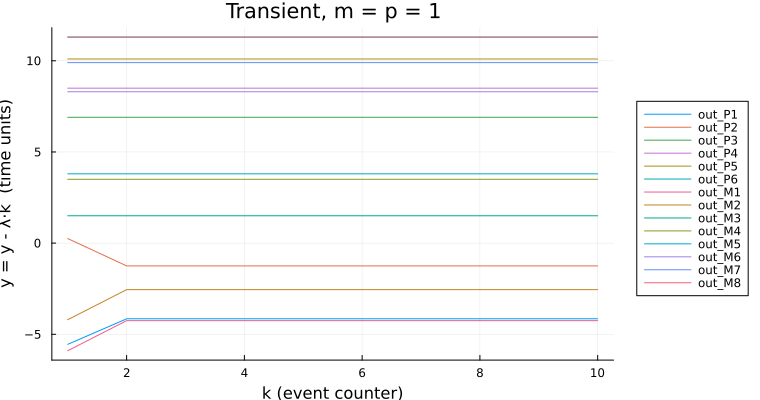

In [13]:
labels = vcat(["out_P$j" for j in 1:npiece], ["out_M$i" for i in 1:nmach])
p = plot(title = "Transient, m = p = 1",
         xlabel = "k (event counter)",
         ylabel = "ỹ = y - λ·k  (time units)")
for j in 1:size(y, 2)
    plot!(p, 1:size(y, 1), y[:, j]; label = labels[j])
end
display(p)

### Periodicity 3 case (`m = p = 3`)

We now switch to **3 machines per class** and **3 pallets per part class**. With those extra buffers every transition can be served *in parallel* three times before waiting for a resource; asymptotically the outputs therefore oscillate with a **steady regime of period 3** (three interleaved trajectories, each a copy of the previous one shifted by one third of a period). Visually: after the transient, the curves $\tilde y[:, j] = y[:, j] - \lambda \cdot k$ are no longer flat but exhibit a pattern that repeats exactly every 3 steps. This is the signature of a flowshop whose asymptotic throughput is still $1/\lambda$, but whose steady-state cycle has length 3 instead of 1 — hence the name "periodicity 3". (The $y$-axis is still in *time units of `PT`*.)

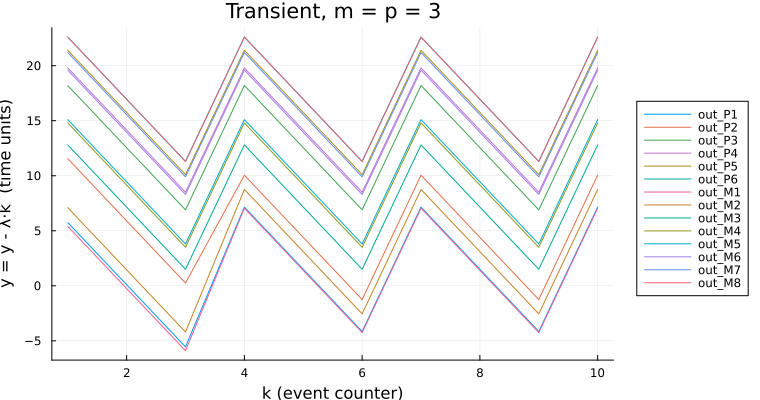

In [14]:
nm3 = fill(3, nmach)
np3 = fill(3, npiece)
_, y3 = flowshop_simu(s, nm3, np3, u)

p2 = plot(title = "Transient, m = p = 3",
          xlabel = "k (event counter)",
          ylabel = "ỹ = y - λ·k  (time units)")
for j in 1:size(y3, 2)
    plot!(p2, 1:size(y3, 1), y3[:, j]; label = labels[j])
end
display(p2)

## Function Summary

| Julia Function | Scilab Equivalent | Description |
|----------------|-------------------|-------------|
| `mpshift(n, t)` | `shift(n, t)` | Shift register with n stages |
| `S1 \| S2` | `S1 \| S2` | Diagonal composition (parallel) |
| `S1 / S2` | `S1 /. S2` | Feedback composition |
| `explicit(S)` | `explicit(S)` | Convert implicit → explicit form |
| `simul(S, u, history)` | `simul(S, u)` | System simulation |
| `flowshop(PT)` | `flowshop(PT)` | Build flowshop system |
| `flowshop_graph(PT, nm, np)` | `flowshop_graph(PT, nm, np)` | Flowshop (T, N) graph |
| `flowshop_simu(s, nm, np, u)` | (manual script) | Encapsulated full simulation |
| `semihoward(T, N)` | `semihoward(T, N)` | Semi-Howard algorithm |